# Transformer From Scratch — Demo

This notebook demonstrates the Transformer model implemented from scratch in PyTorch, following [Attention Is All You Need](https://arxiv.org/abs/1706.03762) (Vaswani et al., 2017).

We will:
1. Load the pre-trained model
2. Translate Italian sentences to English
3. Visualize encoder self-attention weights
4. Visualize decoder cross-attention weights
5. Compare attention heads

## 1. Setup

In [1]:
import os
import sys

# Resolve project root so imports work both interactively and via nbconvert
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

from train import TranslationDataset, PAIRS, translate, encode
from src.transformer import Transformer

print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {"cuda" if torch.cuda.is_available() else "cpu"}')
print(f'Project root    : {PROJECT_ROOT}')

PyTorch version : 2.12.0+cpu
Device          : cpu
Project root    : C:\MyCreativeDev\transformer-from-scratch


## 2. Load the Pre-trained Model

In [2]:
# Rebuild dataset to recover vocabularies
dataset = TranslationDataset(PAIRS)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = Transformer(
    src_vocab_size=len(dataset.src_vocab),
    tgt_vocab_size=len(dataset.tgt_vocab),
    d_model=128,
    num_heads=4,
    num_layers=2,
    d_ff=512,
    dropout=0.0,
).to(device)

model.load_state_dict(torch.load('transformer.pth', map_location=device))
model.eval()

print(f'Model parameters : {model.count_parameters():,}')
print(f'Source vocab size: {len(dataset.src_vocab)}')
print(f'Target vocab size: {len(dataset.tgt_vocab)}')

Model parameters : 932,496
Source vocab size: 17
Target vocab size: 16


## 3. Translations

In [3]:
test_sentences = [
    'il gatto dorme',
    'il cane mangia',
    'la ragazza corre',
    'il bambino piange',
    'la donna legge',
    'il sole splende',
]

print(f'{"Italian":<25} {"English"}')
print('-' * 45)
for sentence in test_sentences:
    translation = translate(model, sentence, dataset)
    print(f'{sentence:<25} {translation}')

Italian                   English
---------------------------------------------
il gatto dorme            the cat sleeps
il cane mangia            the dog eats
la ragazza corre          the girl runs
il bambino piange         the child cries
la donna legge            the woman reads


il sole splende           the sun shines


## 4. Encoder Self-Attention Visualization

Each row represents a token **attending** to all other tokens in the source sequence.
Brighter cells indicate higher attention weight.

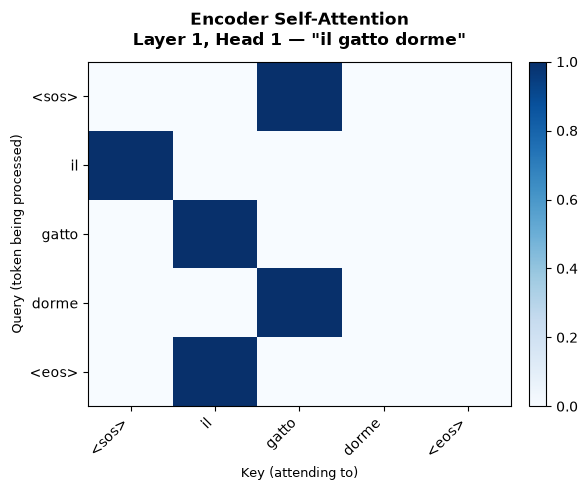

Saved: outputs/encoder_self_attention.png


In [4]:
def get_attention_weights(sentence):
    """Run a forward pass and return all attention weights."""
    src_encoded = encode(sentence, dataset.src_vocab)
    src = torch.tensor(src_encoded).unsqueeze(0).to(device)
    with torch.no_grad():
        encoder_output, src_mask, encoder_attn = model.encode(src)
        tgt_tokens = ['<sos>'] + translate(model, sentence, dataset).split()
        tgt_encoded = [dataset.tgt_vocab[t] for t in tgt_tokens]
        tgt = torch.tensor(tgt_encoded).unsqueeze(0).to(device)
        _, self_attn, cross_attn = model.decode(tgt, encoder_output, src_mask)
    src_tokens = ['<sos>'] + sentence.split() + ['<eos>']
    return encoder_attn, cross_attn, src_tokens, tgt_tokens


def plot_attention(attn_matrix, row_labels, col_labels, title, filename):
    """Plot a single attention heatmap."""
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(attn_matrix, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(col_labels)))
    ax.set_yticks(range(len(row_labels)))
    ax.set_xticklabels(col_labels, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(row_labels, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('Key (attending to)', fontsize=9)
    ax.set_ylabel('Query (token being processed)', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'outputs/{filename}', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: outputs/{filename}')


sentence = 'il gatto dorme'
encoder_attn, cross_attn, src_tokens, tgt_tokens = get_attention_weights(sentence)

# Encoder self-attention — layer 0, head 0
enc_weights = encoder_attn[0][0, 0].cpu().numpy()  # (seq_len, seq_len)
plot_attention(
    enc_weights, src_tokens, src_tokens,
    f'Encoder Self-Attention\nLayer 1, Head 1 — "{sentence}"',
    'encoder_self_attention.png'
)

## 5. Decoder Cross-Attention Visualization

Each row is a generated target token. Each column is a source token.
The heatmap shows **which Italian words the model looks at** when generating each English word.

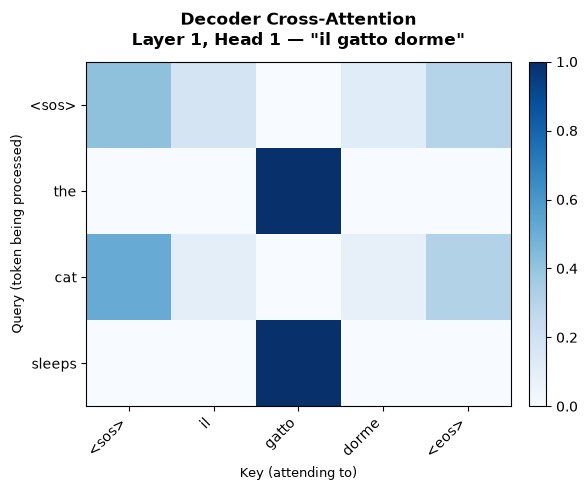

Saved: outputs/decoder_cross_attention.png


In [5]:
# Cross-attention — layer 0, head 0
cross_weights = cross_attn[0][0, 0].cpu().numpy()  # (tgt_len, src_len)
plot_attention(
    cross_weights, tgt_tokens, src_tokens,
    f'Decoder Cross-Attention\nLayer 1, Head 1 — "{sentence}"',
    'decoder_cross_attention.png'
)

## 6. Multi-Head Attention Comparison

All 4 attention heads from the encoder, layer 1.
Each head may specialize in different linguistic relationships.

C:\Users\franc\AppData\Local\Temp\ipykernel_24684\3908938248.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


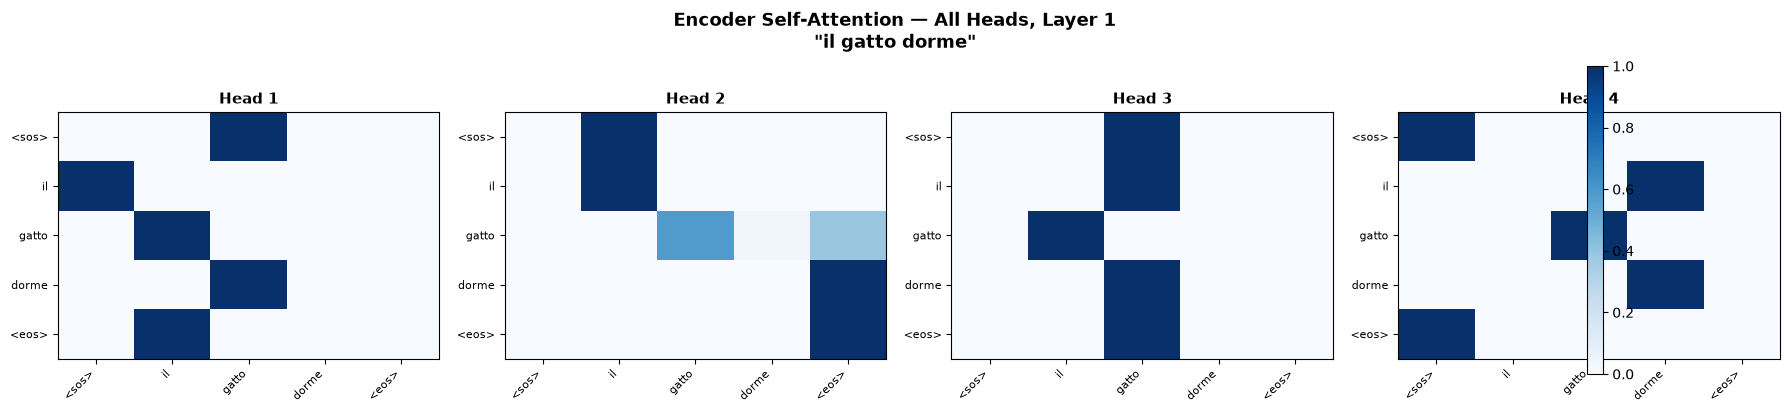

Saved: outputs/all_heads.png


In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for head_idx, ax in enumerate(axes):
    weights = encoder_attn[0][0, head_idx].cpu().numpy()
    im = ax.imshow(weights, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(src_tokens)))
    ax.set_yticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(src_tokens, fontsize=8)
    ax.set_title(f'Head {head_idx + 1}', fontsize=11, fontweight='bold')

fig.suptitle(
    f'Encoder Self-Attention — All Heads, Layer 1\n"{sentence}"',
    fontsize=13, fontweight='bold', y=1.02
)
plt.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
plt.tight_layout()
plt.savefig('outputs/all_heads.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/all_heads.png')